# <span style='font-size:x-large'>**Frequency analysis and Topic Modelling:**</span>

<span style='font-size:small'>After preparing our data for the final analysis, this notebook focuses on analysing the documents to evaluate differences in how carbon credits and community impacts are communicated across sources. Using our processed datasets, we examine how the language and themes differ between official documentation and independent reporting.</span>

<span style='font-size:small'>\-We will begin by calculating and visualising TF\-IDF to get an initial picture of what the documents are about and to identify words that distinguish the messaging between the two sources.</span>

<span style='font-size:small'>\-Next, we will create a document\-feature matrix, which will serve as the input for structural topic modelling \(STM\).</span>

<span style='font-size:small'>\-In this notebook, we will also visualise spatial data to show the location of the study area, specifically the conservancies involved in the Northern Kenya Rangelands Carbon Credit Project.     This map will provide geographic context and help illustrate the region being discussed in the analysis.</span>

<span style='font-size:small'>\-Finally, the results obtained from the modelling will be visualised to support clear communication and interpretation of the research findings.</span>

<span style='font-size:small'><span style='font-size:medium'>**Relevant Lectures:**</span></span>

<span style='font-size:small'>Course 4, Module 11: "Environmental Analysis" by Luke Sanford</span><span style='font-size:small'><span style='font-size:medium'> </span></span><span style='font-size:small'>— Covers loading and visualising spatial data in R</span>

<span style='font-size:small'>Course 4, Module 13: "Text Analysis for Environmental Data " by Luke Sanford — Covers core techniques for analysing environmental text—including cleaning, tokenisation, stop\-word removal, word\-frequency analysis, sentiment analysis, and building custom dictionaries. </span>

<span style='font-size:small'>Course 5, Module 17: "Communicating Environmental Data for Impact" by Simon Queenborough. </span>



In [3]:
# load the packages
library(tidyverse)     # Data manipulation and visualization
library(tidytext)      # Text mining with tidy data principles
library(topicmodels)   # Topic modeling (LDA)
library(SnowballC)     # Stemming
library(tm)            # Text mining utilities
library(knitr)         # For nice table output
library(scales)        # For better plot scales
library(RColorBrewer)  # Color palettes
library(broom)         # Tidy model outputs
library(quanteda)
library(stm)
library(textstem)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: NLP




Attaching package: ‘NLP’




The following object is masked from ‘package:ggplot2’:

    annotate




...

For information on available language packages for 'koRpus', run

  available.koRpus.lang()

and see ?install.koRpus.lang()





Attaching package: ‘koRpus’




The following objects are masked from ‘package:quanteda’:

    tokens, types




The following object is masked from ‘package:tm’:

    readTagged




The following object is masked from ‘package:readr’:

    tokenize




<span style='font-size:x-large'>**TF\-IDF:**</span><span style='font-size:x-large'> </span>

Below, we will do the calculation and visualisation <span style='font-size:small'>to get an initial picture of what the documents are about and to identify words that distinguish the messaging between the two sources</span>



In [4]:
# lets load the dataset

word_counts <- read_csv("data/processed/word_counts.csv")

# TF-IDF to get an overview of words that are unique per each source of document

tfidf_results <- word_counts %>%
  bind_tf_idf(word, source, n) %>%
  arrange(desc(tf_idf))
print(tfidf_results)

# Save full TF-IDF results
write_csv(as.data.frame(tfidf_results),"~/Capstone/results/tables/tfidf_results.csv")

# View the top 10 unique words for each

tfidf_top10 <- tfidf_results %>%
  group_by(source) %>%
  slice_max(tf_idf, n = 10) %>%
  select(source, word, n, tf_idf)

print(tfidf_top10)

# Save top 10 words per source

write_csv(as.data.frame(tfidf_top10),"~/Capstone/results/tables/tfidf_top10.csv")

# Check if they were succesfuly saved

cat("TF-IDF tables saved successfully!\n")


Rows: 2407 Columns: 3


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): source, word
dbl (1): n



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 2,407 × 6
   source      word           n      tf   idf  tf_idf
   <chr>       <chr>      <dbl>   <dbl> <dbl>   <dbl>
 1 Independent county        21 0.00540 0.693 0.00374
 2 official    milk          19 0.00531 0.693 0.00368
 3 official    comms         18 0.00503 0.693 0.00349
 4 official    proportion    18 0.00503 0.693 0.00349
 5 official    scenario      16 0.00447 0.693 0.00310
 6 Independent act           17 0.00437 0.693 0.00303
 7 Independent merti         16 0.00412 0.693 0.00285
 8 Independent validator     16 0.00412 0.693 0.00285
 9 official    positive      14 0.00391 0.693 0.00271
10 Independent pastoral      14 0.00360 0.693 0.00250
# ℹ 2,397 more rows


# A tibble: 23 × 4
# Groups:   source [2]
   source      word              n  tf_idf
   <chr>       <chr>         <dbl>   <dbl>
 1 Independent county           21 0.00374
 2 Independent act              17 0.00303
 3 Independent merti            16 0.00285
 4 Independent validator        16 0.00285
 5 Independent pastoral         14 0.00250
 6 Independent isiolo           11 0.00196
 7 Independent animal           10 0.00178
 8 Independent claim            10 0.00178
 9 Independent nrts             10 0.00178
10 Independent environmental     9 0.00160
# ℹ 13 more rows


TF-IDF tables saved successfully!


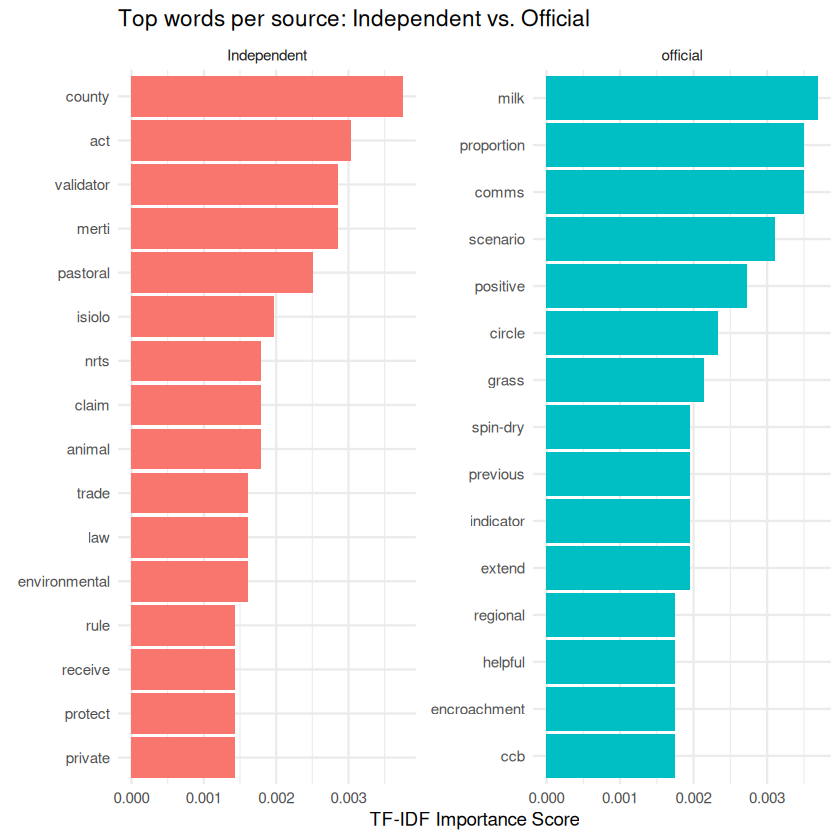

In [5]:
# visualisation of top words per source

tfidf_plot <- tfidf_results %>%
  group_by(source) %>%
  slice_max(tf_idf, n = 15) %>%
  ungroup() %>%
  ggplot(aes(tf_idf, reorder_within(word, tf_idf, source), fill = source)) + 
  geom_col(show.legend = FALSE) +
  scale_y_reordered() + facet_wrap(~source, scales = "free") + 
  labs(title = "Top words per source: Independent vs. Official",
  x = "TF-IDF Importance Score", y = NULL) + 
  theme_minimal()

# show the plot

tfidf_plot

#save the plot

ggsave("results/figures/tfidf_top_keywords_by_source.png",
      plot = tfidf_plot,
      width = 10,
      height = 6,
      dpi = 300)

<span style='font-size:large'>**Interpretations:**</span>

<span style='font-size:medium'>**TF\-IDF Analysis: Divergent Narratives Across Document Sources**</span>

The TF\-IDF analysis suggests an interesting contrast between the two document sources. The Independent documents speak from the perspective of rights, ownership, and the legality of the project, where words such as law, rule, claim, private, and protect are used. What is particularly notable is that this source is tailored to the specific affected community, as evidenced by the explicit mention of Isiolo County, the Merti community, and the word pastoral, all of which point back to the affected communities and their region.

The Official documents, on the other hand, speak from the perspective of positive project outcomes, resembling corporate KPIs and metrics. Terms such as milk, grass, comms, indicator, and CCB \(Climate, Community & Biodiversity standards\) come across as characteristic of a typical institutional report. One may argue that this framing is very generic and corporately positive, given its striking lack of mention of the community itself, the very people the project is intended to serve.

This divergence in language and framing between the two sources provides a strong basis for the Structural Topic Modelling \(STM\) analysis that follows, which will further explore whether these narrative patterns persist across the latent topics within the corpus. 



<span style='font-size:x-large'>**Structural topic modelling:**</span>

We chose to do structural topic modelling because it allows us to group by and does not require removing our metadata \(source\), which is important to our application.



In [6]:
# load data
doc_tokens <- read_csv("data/processed/doc_tokens.csv")

# build a document feature matrix using doc_id as a document unit
doc_dfm <- doc_tokens %>%  
    count(doc_id, word) %>% 
    cast_dfm(doc_id, word, n)

# metadata with source as covariate 
metadata <- doc_tokens %>%
    select (doc_id,source)%>%
    distinct()
# check on the matrix
cat("Documents:", ndoc(doc_dfm), "\n")
cat("Features:", nfeat(doc_dfm), "\n")
cat("Sparsity:", sparsity(doc_dfm), "\n")
cat("DFM dimensions:", dim(doc_dfm), "\n")
cat("Documents:", nrow(metadata), "\n")
print(doc_dfm)
print(metadata)

# Convert DFM to STM format
stm_input <- convert(doc_dfm, to = "stm")
# Check conversion
cat("STM input ready!\n")
cat("Documents:", length(stm_input$documents), "\n")
cat("Vocab size:", length(stm_input$vocab), "\n")

Rows: 7463 Columns: 5


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): doc_id, doc_name, source, word
dbl (1): year



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Documents: 5 


Features: 1982 


...

Document-feature matrix of: 5 documents, 1,982 features (66.28% sparse) and 0 docvars.
        features
docs     ability abrupt abstract access accord accuse acknowledge acled acre
  doc_01       1      1        1      9      2      1           1     1    1
  doc_02       2      0        0      0      7      0           0     0    0
  doc_03       0      0        0      2      2      1           0     0    0
  doc_04       2      0        0      4      1      0           0     0    0
  doc_05       3      0        0      5      2      0           0     0    0
        features
docs     action
  doc_01      2
  doc_02      1
  doc_03      0
  doc_04      1
  doc_05      1
[ reached max_nfeat ... 1,972 more features ]


# A tibble: 5 × 2
  doc_id source     
  <chr>  <chr>      
1 doc_01 Independent
2 doc_02 Independent
3 doc_03 Independent
4 doc_04 official   
5 doc_05 official   


STM input ready!


Documents: 5 


Vocab size: 1982 


In [7]:
# Run STM model
set.seed(123)
stm_model <- stm(
  documents = stm_input$documents,
  vocab = stm_input$vocab,
  K = 4,                      
  prevalence = ~ source,      
  data = metadata,
  verbose = TRUE              
)
# Top words per topic
cat("Top words per topic:\n")
labelTopics(stm_model)

# Topic proportions per document
cat("\nTopic proportions per document:\n")
doc_topics <- make.dt(stm_model, metadata)
print(doc_topics)

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 	....
	 Recovering initialization...
 	...................
Initialization complete.
.....
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -6.190) 
.....
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -6.151, relative change = 6.357e-03) 
.....
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -6.151, relative change = 3.229e-05) 
.....
Completed E-Step (0 seconds). 
Completed M-Step. 
Model Converged 


Top words per topic:


Topic 1 Top Words:
 	 Highest Prob: household, graze, benefit, plan, livestock, increase, survey 
 	 FREX: circle, scenario, milk, comms, positive, proportion, extend 
 	 Lift: administrative, analysis, announce, antagonistic, anticipatory, appropriately, approximately 
 	 Score: household, survey, administrative, woman, benefit, baseline, milk 
Topic 2 Top Words:
 	 Highest Prob: merti, livestock, land, establish, people, establishment, gun 
 	 FREX: merti, gun, osman, lakole, mohamed, plain, cherab 
 	 Lift: abandon, abdi, abdirahman, abundance, adirt, administration, advocacy 
 	 Score: abandon, merti, gun, osman, lakole, plain, mohamed 
Topic 3 Top Words:
 	 Highest Prob: resource, conflict, pastoralist, pastoral, local, climate, land 
 	 FREX: pastoral, resource, conflict, pastoralist, air, colonial, exacerbate 
 	 Lift: abrupt, abstract, acknowledge, acled, acre, adano, administer 
 	 Score: abrupt, pastoral, resource, conflict, pastoralist, environmental, air 
Topic 4 Top Words:


Topic proportions per document:


   docnum       Topic1       Topic2       Topic3       Topic4 doc_id
    <int>        <num>        <num>        <num>        <num> <char>
1:      1 0.0001232485 1.113940e-04 9.996116e-01 0.0001537284 doc_01
2:      2 0.0002492458 7.877022e-05 9.119653e-05 0.9995807875 doc_02
3:      3 0.0001513795 9.995066e-01 1.488895e-04 0.0001931421 doc_03
4:      4 0.9996402066 7.241205e-05 8.672608e-05 0.0002006552 doc_04
5:      5 0.9997182634 6.337994e-05 7.622979e-05 0.0001421268 doc_05
        source
        <char>
1: Independent
2: Independent
3: Independent
4:    official
5:    official


<span style='font-size:x-large'>**STM Results Analysis**</span>

Now that we have STM model results, we are moving to interpreting the results to directly answer our research question, "What are the thematic differences in how carbon credits and community impacts are discussed in official project documentation vs independent reporting for the Northern Kenya Rangelands Carbon Project?” 

<span style='font-size:medium'>**We do this in three steps**</span>

1. **Top Words per Topic \(Beta Matrix\):** We extract the top words per topic using the beta matrix, which tells us the probability of each word belonging to a topic. This helps us label and interpret what each topic is about

2. **Topic Distribution by Source:** We link each topic back to its document source \(Independent vs Official\) to see which topics dominate each source. This is where we can directly observe the thematic differences between the two document types.

3. **Estimating the Effect of Source on Topic Prevalence:** We then statistically test whether the source of a document, independent 
   or Official, predicts which topics appear in it. 



In [8]:
# The words extracted here will be used to label the topics by identifying
# the common idea or theme shared across the most representative terms.

# Extract topic–word probabilities (beta),
topic_terms <- tidy(stm_model, matrix = "beta")

# Get top 10 words per topic
top_terms <- topic_terms %>%
  group_by(topic) %>%
  slice_max(beta, n = 15) %>%
  ungroup() %>%
  arrange(topic, -beta)

# View result
top_terms
write_csv(top_terms, "~/Capstone/results/tables/stm_top_terms.csv")
cat("Top terms table saved successfully!\n")

topic,term,beta
<int>,<chr>,<dbl>
1,household,0.029087849
1,graze,0.028808020
1,benefit,0.017619410
1,plan,0.015103903
1,livestock,0.013703912
1,increase,0.012864763
1,survey,0.012585905
1,woman,0.010348443
1,stakeholder,0.009789410


Top terms table saved successfully!


In [9]:
#based on the top words per topic we are going to label the topic

topic_labels <- c(
  "1" = "Program Outcomes & Monitoring",
  "2" = "Community Identity & Place",
  "3" = "Resource Rights & Conflict",
  "4" = "Legal Accountability & Validation"
)
#link topics back to the source and Get topic proportions with source
doc_topics_labeled <- doc_topics %>%
  mutate(dominant_topic = case_when(
    Topic1 > 0.5 ~ "Program Outcomes & Monitoring",
    Topic2 > 0.5 ~ "Community Identity & Place",
    Topic3 > 0.5 ~ "Resource Rights & Conflict",
    Topic4 > 0.5 ~ "Legal Accountability & Validation"
  ))

print(doc_topics_labeled %>% select(doc_id, source, dominant_topic))

#save the plot
write_csv(doc_topics_labeled, "~/Capstone/results/tables/doc_topics_labeled.csv")
cat("Top terms table saved successfully!\n")


   doc_id      source                    dominant_topic
   <char>      <char>                            <char>
1: doc_01 Independent        Resource Rights & Conflict
2: doc_02 Independent Legal Accountability & Validation
3: doc_03 Independent        Community Identity & Place
4: doc_04    official     Program Outcomes & Monitoring
5: doc_05    official     Program Outcomes & Monitoring


Top terms table saved successfully!


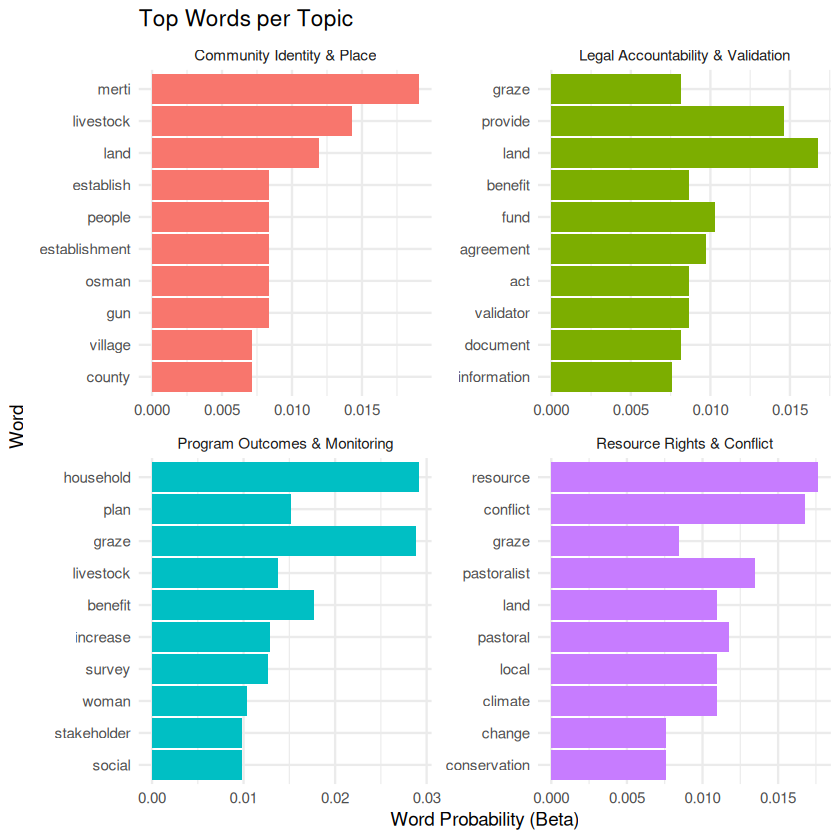

In [10]:
# Compare top words across all 4 topics
beta_plot <- tidy(stm_model, matrix = "beta") %>%
  group_by(topic) %>%
  slice_max(beta, n = 10) %>%
  ungroup() %>%
  mutate(topic = recode(as.character(topic),
    "1" = "Program Outcomes & Monitoring",
    "2" = "Community Identity & Place",
    "3" = "Resource Rights & Conflict",
    "4" = "Legal Accountability & Validation"
  )) %>%
  ggplot(aes(beta, reorder(term, beta), fill = topic)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  labs(
    title = "Top Words per Topic",
    x = "Word Probability (Beta)",
    y = "Word"
  ) +
  theme_minimal()

print(beta_plot)

#save the plot

ggsave("~/Capstone/results/figures/topic_words_plot.png",
       plot = beta_plot, width = 12, height = 8, dpi = 300)

<span style='font-size:large'>**Interpretation: Top words per topic**</span>

The graph presents the top words associated with each of the four STM\-identified topics, illustrating how each theme is constructed from recurring terminology.

**Below are some observations:**

**The Program Outcomes & Monitoring topic** is dominated by Official documents, which centre on words like household, graze, benefit, survey and stakeholder, reflecting a monitoring and evaluation that suggests typical institutional reporting language. Notably, the word woman appears here, suggesting that gender is framed within the official narrative as a program metric rather than a rights issue.

**The Resource Rights & Conflict and Community Identity & Place topics,** both associated with Independent documents, are dominated by words like resource, conflict, pastoralist, climate and conservation, pointing to a narrative of environmental pressure and land contestation. At the same time, merti, osman, gun and village ground the discourse in specific people and places, which highlighted the human reality that official documentation leaves out.

**The Legal Accountability & Validation topic** uses words such as validator, act, agreement, and document, suggesting a focus on the project's legality and contractual obligations to the community.

Together, these four topics suggest a visible contrast between the two document sources, which do not just use different language but also a different narrative.



topic_distribution_plot saved successfully!


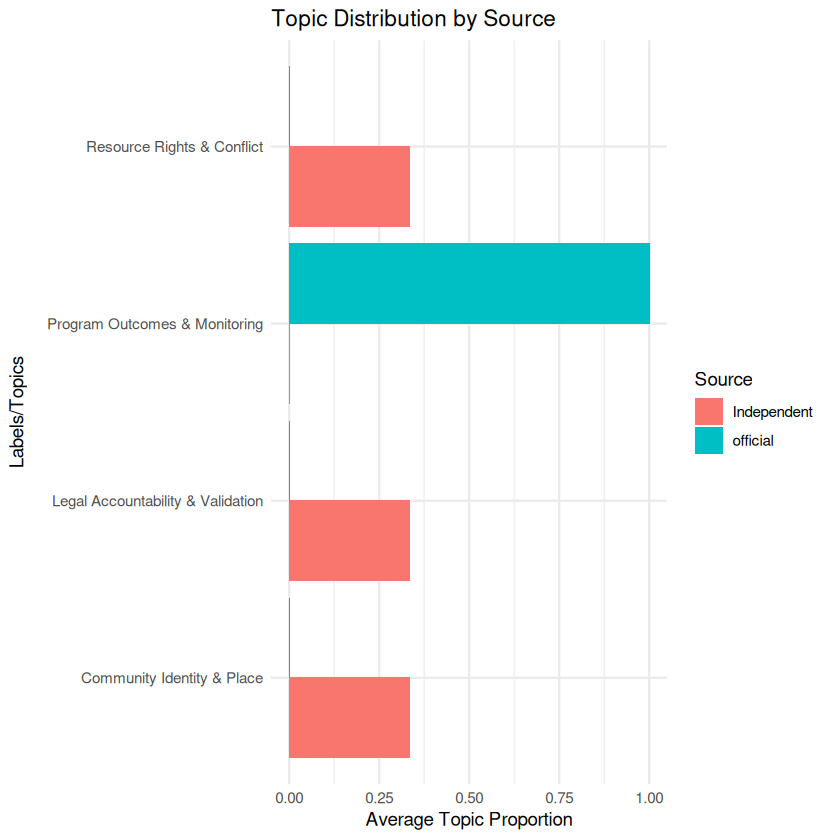

In [11]:
# Plot topic proportions by source
topic_distribution_plot <- doc_topics %>%
  pivot_longer(
    cols = starts_with("Topic"),
    names_to = "topic",
    values_to = "proportion"
  ) %>%
# average by source
  group_by(source, topic) %>%
  summarise(proportion = mean(proportion), .groups = "drop") %>%
  
  # Rename topics to labels/themes
  mutate(topic = recode(topic,
    "Topic1" = "Program Outcomes & Monitoring",
    "Topic2" = "Community Identity & Place",
    "Topic3" = "Resource Rights & Conflict",
    "Topic4" = "Legal Accountability & Validation"
  )) %>%
# Plot
  ggplot(aes(x = topic, y = proportion, fill = source)) +
  geom_col(position = "dodge") +
  coord_flip() +
  labs(
    title = "Topic Distribution by Source",
    x = "Labels/Topics",
    y = "Average Topic Proportion",
    fill = "Source"
  ) +
  theme_minimal()

# Display it
print(topic_distribution_plot)

# Save the plot
 ggsave(
  filename = "~/Capstone/results/figures/topic_distribution by_Source.png",
  plot = topic_distribution_plot,
  width = 10,
  height = 6,
  dpi = 300
)

cat("topic_distribution_plot saved successfully!\n")


<span style='font-size:large'>**Interpretations: Topic distribution by source**</span>

The graph shows how the four STM\-identified topics are distributed across the two document sources. The findings show that official documents are almost entirely dominated by a single topic, "Program Outcomes & Monitoring ", with a proportion close to 1.0, suggesting that official reporting is thematically narrow and focused on measurable project performance. 

In contrast, Independent documents spread evenly across three topics: Resource Rights & Conflict, Legal Accountability & Validation, and Community Identity & Place, each carrying roughly equal weight. This indicates that independent reporting captures a much broader and more complex picture of the project, one that includes the community's lived experience, legal scrutiny, and land rights concerns that are absent from the official narrative.



agg_record_2008005163 
                    2

Topic prevalence plot saved successfully!


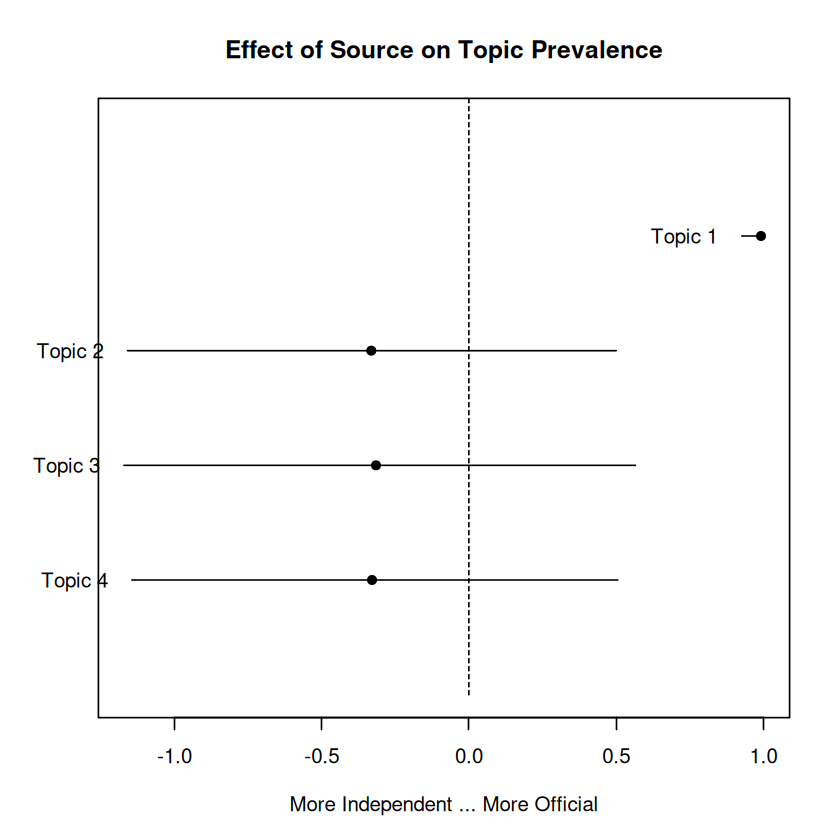

In [24]:
#Topic prevalence plot

# Estimate effect of source on topic prevalence
prep <- estimateEffect(1:4 ~ source, stm_model, meta = metadata, uncertainty = "Global")

#plot it
plot(prep, covariate = "source", topics = 1:4,
     model = stm_model, method = "difference",
     cov.value1 = "official", cov.value2 = "Independent",
     xlab = "More Independent ... More Official",
     main = "Effect of Source on Topic Prevalence",
     labeltype = "custom",
     custom.labels = c(
       "Topic 1",
       "Topic 2",
       "Topic 3",
       "Topic 4"
     ))

# Record and save
recorded_plot <- recordPlot()
png("~/Capstone/results/figures/topic_prevalence_plot.png",
    width = 800, height = 900, res = 120)
replayPlot(recorded_plot)
dev.off()
cat("Topic prevalence plot saved successfully!\n")

<span style='font-size:large'>**Interpretation: Effect of source on Topic prevalence**</span>

The figure above shows the estimated effect of document source on topic prevalence, where points to the right indicate a stronger association with Official documents and points to the left indicate a stronger association with Independent documents. Topic 1 \(Program Outcomes & Monitoring\) lean heavily to the right, confirming its strong association with Official documents. Topics 2, 3 and 4 all sit to the left of zero, indicating they are more prevalent in Independent documents. The wide confidence intervals across all topics reflect the small sample size of 5 documents, meaning the direction of these effects is meaningful, but statistical significance should be interpreted with caution. Nevertheless, the consistent directional pattern across all four topics emphasises the thematic divergence identified in the TF\-IDF and topic distribution analyses.



**Spatial Context: Northern Kenya Rangelands Carbon Project**

The project spans 20 NRT \(Northern Rangelands Trust\) community conservancies in northern Kenya. Below we visualise the project boundaries, highlighting the Biliqo Bulesa conservancy, which was established in Isiolo County, and Merti in Isiolo County, a community that featured prominently in our textual analysis. 


In [3]:
# Install and load required packages
library(sf)
library(ggplot2)
library(tidyverse)

# Read the KML file
project_boundary <- st_read("~/Capstone/data/raw/NRT_carbon project Conservancy boundaries.kml")


Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Reading layer `NRT_carbon_project_Conservancy_boundaries' from data source 
  `/home/user/Capstone/data/raw/NRT_carbon project Conservancy boundaries.kml' 
  using driver `LIBKML'
Simple feature collection with 20 features and 44 fields
Geometry type: POLYGON
Dimension:     XYZ
Bounding box:  xmin: 36.07075 ymin: 0.1305164 xmax: 38.96049 ymax: 2.585508
z_range:       zmin: 0 zmax: 0
Geodetic CRS:  WGS 84


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


Map saved successfully!


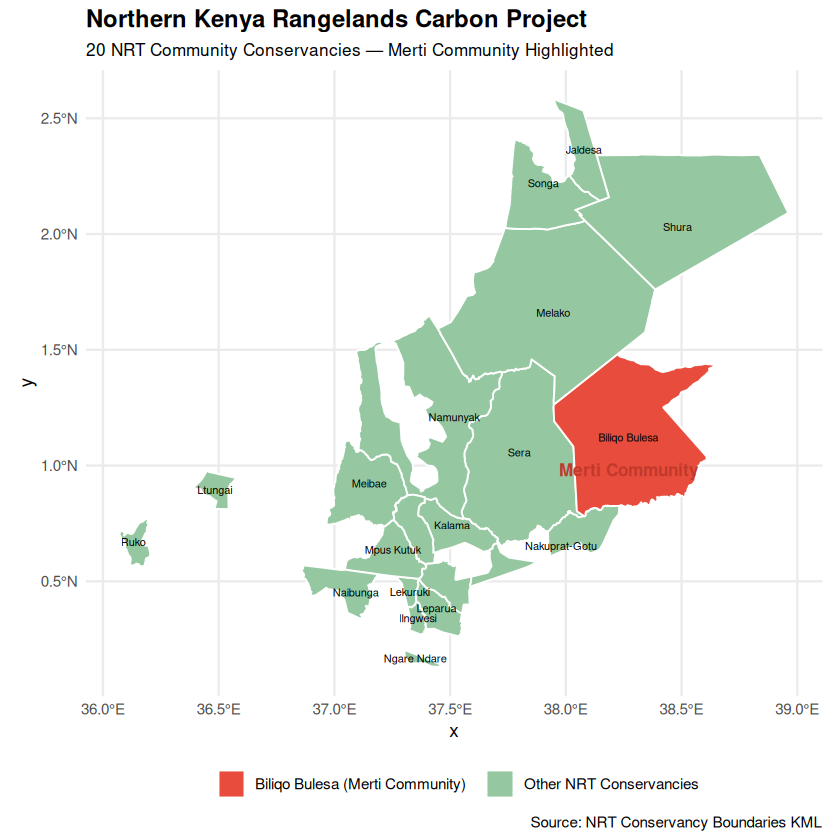

In [8]:
# Map  - All 20 conservancies, hiighlighting Biliqo Bulesa within all conservancies

conservancy_map <- ggplot(project_boundary %>%
  mutate(highlight = ifelse(Name == "Biliqo Bulesa",
                            "Biliqo Bulesa (Merti Community)",
                            "Other NRT Conservancies"))) +
  geom_sf(aes(fill = highlight), color = "white", linewidth = 0.4) +
  scale_fill_manual(values = c(
    "Biliqo Bulesa (Merti Community)" = "#e74c3c",
    "Other NRT Conservancies" = "#95c8a0"
  )) +
  geom_sf_text(aes(label = Name), size = 2.2, color = "black", check_overlap = TRUE) +
  annotate("text",
           x = biliqo_centroid$X,
           y = biliqo_centroid$Y - 0.15,
           label = "Merti Community",
           size = 3.5, color = "#c0392b", fontface = "bold") +
  labs(
    title = "Northern Kenya Rangelands Carbon Project",
    subtitle = "20 NRT Community Conservancies — Merti Community Highlighted",
    fill = "",
    caption = "Source: NRT Conservancy Boundaries KML"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 10)
  )

# Display
suppressWarnings(print(conservancy_map))

# Save
ggsave(
  filename = "~/Capstone/results/figures/conservancy_map.png",
  plot = conservancy_map,
  width = 10,
  height = 8,
  dpi = 300
)

cat("Map saved successfully!\n")

In this project, we explored the thematic differences in how carbon credits and community impacts are discussed across official and independent documentation of the Northern Kenya Rangelands Carbon Project. Our analysis showed a clear difference between the two sources. TF\-IDF showed that official documents are framed around reporting and KPIs, while independent sources place greater emphasis on community experiences and social justice.

Structural Topic Modelling further identified four distinct themes, which we interpreted and labelled based on the top words in each topic. Finally, we visualised the spatial distribution of conservancies to ground these findings geographically, highlighting the Biliqo Bulesa Conservancy in Isiolo county, frequently referenced in independent documents alongside the Merti community. Established in 2007 as the first conservancy in Isiolo County, Biliqo Bulesa combines communal lands from Biliqo and Bulesa within Merti Sub\-County, covering a total area of 327,600 hectares. A community whose lived reality is well documented in independent reporting but largely absent from official project documentation.

